# Single-Book SFT Ablation — Combined Results

Pulls all single-book SFT evaluation runs from the **`eval-all`** W&B project, then compiles a LaTeX table for the paper.

**Benchmarks**: GoldCoin-HIPAA (applicability + compliance), PrivacyLens (QA probing + leakage), VLM-GeoPrivacy (Q7)

**Books**: 1984 (`book:1984`), Pride and Prejudice (`book:1342`)

**Model**: Qwen3.5-9B + SFT (single-book normative simulacra)

In [1]:
import wandb
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Latex

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Configuration ──────────────────────────────────────────────────────────────
WANDB_ENTITY = "uair"
WANDB_PROJECT = "eval-all"

# Display names for books (tag suffix → paper label)
BOOK_DISPLAY = {
    "1984": "\\textit{1984}",
    "1342": "\\textit{Pride \\& Prejudice}",
}

# Desired row order
BOOK_ORDER = ["1984", "1342"]

api = wandb.Api()
print(f"Connected to W&B entity={WANDB_ENTITY}, project={WANDB_PROJECT}")

Connected to W&B entity=uair, project=eval-all


## 1. Fetch runs from W&B

Filter for runs tagged `single_book`. Each run also has a `book:<id>` tag identifying which novel's normative simulacra were used for SFT.

In [2]:
runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["single_book"]}},
)
print(f"Found {len(runs)} single_book-tagged runs")

for r in runs[:5]:
    print(f"\n  {r.name}  (state={r.state})")
    print(f"    tags: {r.tags}")
    print(f"    config keys: {list(r.config.keys())[:15]}")
    summary_keys = [k for k in r.summary.keys() if "eval" in k or "accuracy" in k or "leakage" in k]
    print(f"    eval summary keys: {summary_keys}")

Found 18 single_book-tagged runs

  full_eval-goldcoin_hipaa-orchestrator-20260326-004010  (state=finished)
    tags: ['bench:goldcoin_hipaa', 'book:1984', 'family:qwen3.5', 'finetuned', 'single_book', 'task:compliance']
    config keys: ['model', 'slurm', 'system', 'runtime', 'compute.cpu_count', 'compute.gpu_count', 'compute.memory_gb', 'compute.cpu_architecture']
    eval summary keys: ['compute_metrics/eval/accuracy', 'compute_metrics/eval/applicable/correct', 'compute_metrics/eval/applicable/error', 'compute_metrics/eval/applicable/f1', 'compute_metrics/eval/applicable/precision', 'compute_metrics/eval/applicable/recall', 'compute_metrics/eval/applicable/support', 'compute_metrics/eval/applicable/total', 'compute_metrics/eval/cm/applicable_pred_applicable', 'compute_metrics/eval/cm/applicable_pred_not_applicable', 'compute_metrics/eval/cm/forbid_pred_forbid', 'compute_metrics/eval/cm/forbid_pred_permit', 'compute_metrics/eval/cm/not_applicable_pred_applicable', 'compute_metrics/ev

## 2. Extract metrics into a unified DataFrame

Orchestrator runs contain the evaluation metrics. We key each row by both **book** and **benchmark** (dagspace).

In [3]:
def extract_run_metrics(run) -> dict | None:
    """Extract structured metrics from a single W&B run.
    
    Metrics live on orchestrator runs. checkpoint_name is nested under config.model.
    GoldCoin runs contain both applicability + compliance metrics in one run.
    Applicability F1 = mean(applicable_f1, not_applicable_f1).
    Compliance F1 = mean(permit_f1, forbid_f1).
    """
    config = run.config
    summary = run.summary
    tags = set(run.tags)
    
    checkpoint = config.get("model", {}).get("checkpoint_name", "")
    if not checkpoint:
        return None
    
    # Extract book tag
    book_id = None
    for t in tags:
        if t.startswith("book:"):
            book_id = t.split(":", 1)[1]
            break
    if not book_id:
        return None
    
    # Extract dagspace
    dagspace = None
    for t in tags:
        if t.startswith("bench:"):
            dagspace = t.split(":", 1)[1]
            break
    if not dagspace:
        return None
    
    row = {"book": book_id, "checkpoint": checkpoint, "dagspace": dagspace, "run_id": run.id}
    has_metrics = False
    
    if dagspace == "goldcoin_hipaa":
        app_f1 = summary.get("compute_metrics/eval/applicable/f1")
        notapp_f1 = summary.get("compute_metrics/eval/not_applicable/f1")
        permit_f1 = summary.get("compute_metrics/eval/permit/f1")
        forbid_f1 = summary.get("compute_metrics/eval/forbid/f1")
        if app_f1 is not None and notapp_f1 is not None:
            row["gc_applicability_f1"] = (app_f1 + notapp_f1) / 2
            has_metrics = True
        if permit_f1 is not None and forbid_f1 is not None:
            row["gc_compliance_f1"] = (permit_f1 + forbid_f1) / 2
            has_metrics = True
    elif dagspace == "privacylens":
        qa_acc = summary.get("compute_metrics/eval/qa_accuracy")
        leak = summary.get("compute_metrics/eval/leakage_rate")
        if qa_acc is not None or leak is not None:
            row["pl_qa_accuracy"] = qa_acc
            row["pl_leakage_rate"] = leak
            has_metrics = True
    elif dagspace == "vlm_geoprivacy_bench":
        q7_acc = summary.get("compute_metrics/eval/Q7/accuracy")
        if q7_acc is not None:
            row["vlm_q7_accuracy"] = q7_acc
            has_metrics = True
    
    return row if has_metrics else None


rows = []
for r in runs:
    m = extract_run_metrics(r)
    if m is not None:
        rows.append(m)

df_raw = pd.DataFrame(rows)
print(f"Extracted {len(df_raw)} metric rows")
print(f"Books: {sorted(df_raw['book'].unique())}")
print(f"Benchmarks: {sorted(df_raw['dagspace'].unique())}")
display(df_raw)

Extracted 6 metric rows
Books: ['1342', '1984']
Benchmarks: ['goldcoin_hipaa', 'privacylens', 'vlm_geoprivacy_bench']


,book,checkpoint,dagspace,run_id,gc_applicability_f1,gc_compliance_f1,pl_qa_accuracy,pl_leakage_rate,vlm_q7_accuracy
0,1984,Qwen3.5-9B+sft_only,goldcoin_hipaa,mmvyhb06,0.734,0.776,NaN,NaN,NaN
1,1342,Qwen3.5-9B+sft_only,goldcoin_hipaa,guofz58b,0.734,0.776,NaN,NaN,NaN
2,1342,Qwen3.5-9B+sft_only,privacylens,7edk65ws,NaN,NaN,0.979,0.815,NaN
3,1984,Qwen3.5-9B+sft_only,privacylens,jxy345n3,NaN,NaN,0.979,0.815,NaN
4,1342,Qwen3.5-9B+sft_only,vlm_geoprivacy_bench,yhp1e74h,NaN,NaN,NaN,NaN,0.599
5,1984,Qwen3.5-9B+sft_only,vlm_geoprivacy_bench,dfusgt2w,NaN,NaN,NaN,NaN,0.599


## 3. Pivot into paper table

One row per book. De-duplicate by (book, dagspace), then merge across benchmarks.

In [4]:
# De-duplicate: keep last run per (book, dagspace)
df_dedup = df_raw.drop_duplicates(subset=["book", "dagspace"], keep="last")

# ── GoldCoin: Applicability F1, Compliance F1 ──
gc = df_dedup[df_dedup["dagspace"] == "goldcoin_hipaa"][
    ["book", "gc_applicability_f1", "gc_compliance_f1"]
].rename(columns={
    "gc_applicability_f1": "App F1",
    "gc_compliance_f1": "Comp F1",
})

# ── PrivacyLens: QA Acc, Leakage Rate ──
pl = df_dedup[df_dedup["dagspace"] == "privacylens"][
    ["book", "pl_qa_accuracy", "pl_leakage_rate"]
].rename(columns={
    "pl_qa_accuracy": "QA Acc",
    "pl_leakage_rate": "Leak Rate",
})

# ── VLM-GeoPrivacy: Q7 Acc ──
vlm = df_dedup[df_dedup["dagspace"] == "vlm_geoprivacy_bench"][
    ["book", "vlm_q7_accuracy"]
].rename(columns={
    "vlm_q7_accuracy": "Q7 Acc",
})

# ── Merge on book ──
df_table = gc.merge(pl, on="book", how="outer") \
              .merge(vlm, on="book", how="outer")

# Map to display names and reorder
df_table["Book"] = df_table["book"].map(BOOK_DISPLAY).fillna(df_table["book"])
df_table = df_table.set_index("book").drop(columns=["Book"])

# Reorder
idx = [b for b in BOOK_ORDER if b in df_table.index]
extra = [b for b in df_table.index if b not in BOOK_ORDER]
df_table = df_table.loc[idx + extra]

# Convert [0,1] to percentage
for c in df_table.columns:
    df_table[c] = df_table[c] * 100

display(df_table.round(2))

,App F1,Comp F1,QA Acc,Leak Rate,Q7 Acc
book,,,,,
1984,73.410,77.600,97.900,81.540,59.900
1342,73.410,77.600,97.900,81.540,59.900


## 4. Generate LaTeX table

In [5]:
def build_latex_table(df: pd.DataFrame, book_display: dict) -> str:
    """Generate a booktabs LaTeX table from the pivoted DataFrame."""
    
    gc_cols = ["App F1", "Comp F1"]
    pl_cols = ["QA Acc", "Leak Rate"]
    vlm_cols = ["Q7 Acc"]
    all_cols = [c for c in gc_cols + pl_cols + vlm_cols if c in df.columns and df[c].notna().any()]
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Single-book SFT ablation (Qwen3.5-9B). Each row uses normative simulacra extracted from a single novel. "
                 r"(\%). $\downarrow$ = lower is better.}")
    lines.append(r"\label{tab:single-book-ablation}")
    lines.append(r"\begin{tabular}{l" + "c" * len(all_cols) + "}")
    lines.append(r"\toprule")
    
    # Header row 1: benchmark groups
    gc_present = [c for c in gc_cols if c in all_cols]
    pl_present = [c for c in pl_cols if c in all_cols]
    vlm_present = [c for c in vlm_cols if c in all_cols]
    
    group_header = " "
    col_idx = 2
    cmidrules = []
    if gc_present:
        group_header += rf" & \multicolumn{{{len(gc_present)}}}{{c}}{{\textbf{{GoldCoin-HIPAA}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(gc_present) - 1}}}")
        col_idx += len(gc_present)
    if pl_present:
        group_header += rf" & \multicolumn{{{len(pl_present)}}}{{c}}{{\textbf{{PrivacyLens}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(pl_present) - 1}}}")
        col_idx += len(pl_present)
    if vlm_present:
        group_header += rf" & \multicolumn{{{len(vlm_present)}}}{{c}}{{\textbf{{VLM-GeoPri.}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(vlm_present) - 1}}}")
    
    lines.append(group_header + r" \\")
    lines.append(" ".join(cmidrules))
    
    # Header row 2
    col_labels = {
        "App F1": r"App F1",
        "Comp F1": r"Comp F1",
        "QA Acc": r"QA Acc",
        "Leak Rate": r"Leak $\downarrow$",
        "Q7 Acc": r"Q7 Acc",
    }
    col_headers = [r"\textbf{SFT Source}"] + [col_labels.get(c, c) for c in all_cols]
    lines.append(" & ".join(col_headers) + r" \\")
    lines.append(r"\midrule")
    
    # Bold best per column
    lower_better = {"Leak Rate"}
    best = {}
    for col in all_cols:
        vals = df[col].dropna()
        if len(vals) == 0:
            continue
        best[col] = vals.min() if col in lower_better else vals.max()
    
    for book_id, row in df.iterrows():
        display_name = book_display.get(book_id, book_id)
        cells = [display_name]
        for col in all_cols:
            val = row.get(col, np.nan)
            txt = "---" if pd.isna(val) else f"{val:.1f}"
            if col in best and not pd.isna(val) and val == best[col]:
                txt = rf"\textbf{{{txt}}}"
            cells.append(txt)
        lines.append(" & ".join(cells) + r" \\")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


latex = build_latex_table(df_table, BOOK_DISPLAY)
print(latex)

\begin{table}[t]
\centering
\caption{Single-book SFT ablation (Qwen3.5-9B). Each row uses normative simulacra extracted from a single novel. (\%). $\downarrow$ = lower is better.}
\label{tab:single-book-ablation}
\begin{tabular}{lccccc}
\toprule
  & \multicolumn{2}{c}{\textbf{GoldCoin-HIPAA}} & \multicolumn{2}{c}{\textbf{PrivacyLens}} & \multicolumn{1}{c}{\textbf{VLM-GeoPri.}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-6}
\textbf{SFT Source} & App F1 & Comp F1 & QA Acc & Leak $\downarrow$ & Q7 Acc \\
\midrule
\textit{1984} & \textbf{73.4} & \textbf{77.6} & \textbf{97.9} & \textbf{81.5} & \textbf{59.9} \\
\textit{Pride \& Prejudice} & \textbf{73.4} & \textbf{77.6} & \textbf{97.9} & \textbf{81.5} & \textbf{59.9} \\
\bottomrule
\end{tabular}
\end{table}


## 5. Save to .tex file

In [6]:
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "single_book_ablation.tex"
out_path.write_text(latex)
print(f"Saved to {out_path.resolve()}")

Saved to /share/pierson/matt/UAIR/notebooks/COLM26/tables/single_book_ablation.tex


## 6. Comparative bar plots

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Plot style ───────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
BOOK_LABELS = {"1984": "1984", "1342": "Pride & Prejudice"}

books = list(df_table.index)
book_labels = [BOOK_LABELS.get(b, b) for b in books]
colors = {b: PALETTE[i % len(PALETTE)] for i, b in enumerate(books)}
print(f"Plotting {len(books)} books: {book_labels}")

Plotting 2 books: ['1984', 'Pride & Prejudice']


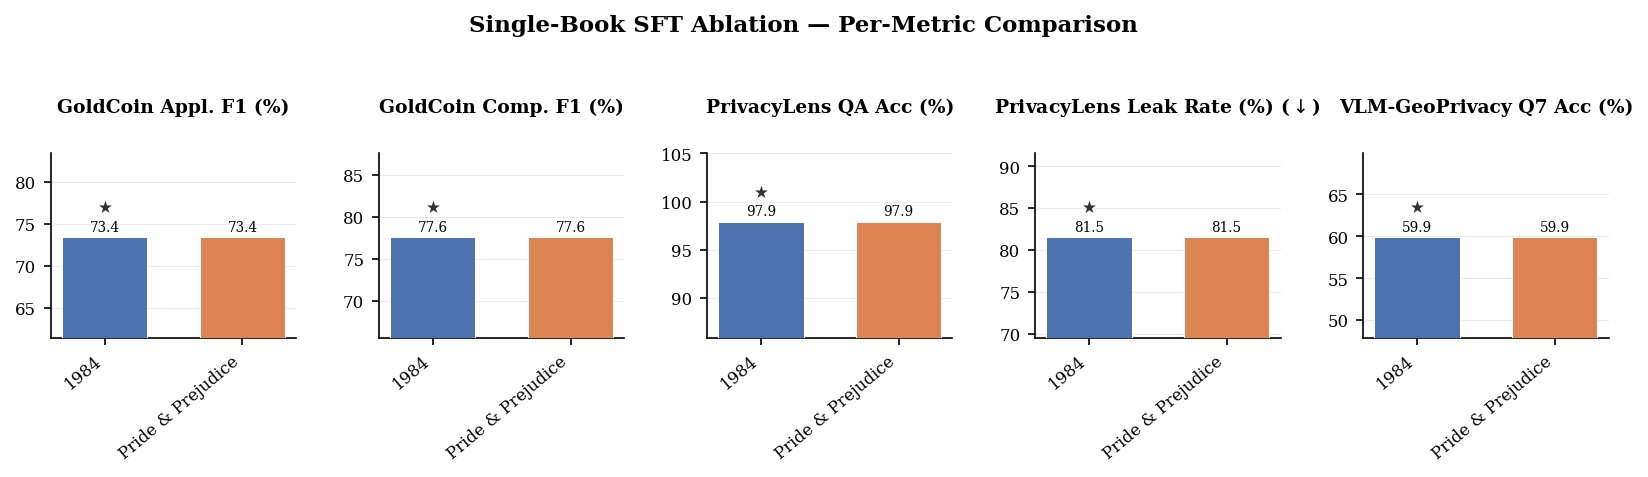

In [8]:
# ── Figure 1: Per-benchmark bar charts (one panel per metric) ──────────────

metric_spec = [
    ("App F1",    "GoldCoin Appl. F1 (%)",    True),
    ("Comp F1",   "GoldCoin Comp. F1 (%)",   True),
    ("QA Acc",    "PrivacyLens QA Acc (%)",    True),
    ("Leak Rate", "PrivacyLens Leak Rate (%)", False),
    ("Q7 Acc",    "VLM-GeoPrivacy Q7 Acc (%)",    True),
]
metric_spec = [(col, label, hb) for col, label, hb in metric_spec
               if col in df_table.columns and df_table[col].notna().any()]

n = len(metric_spec)
fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 3), squeeze=False)
axes = axes[0]

for ax, (col, label, higher_better) in zip(axes, metric_spec):
    vals = df_table[col].reindex(books)
    bar_colors = [colors[b] for b in books]
    bars = ax.bar(range(len(books)), vals, color=bar_colors, width=0.62,
                   edgecolor="white", linewidth=0.5, zorder=3)

    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    f"{v:.1f}", ha="center", va="bottom",
                    fontsize=6.5, fontweight="medium")

    ax.set_xticks(range(len(books)))
    ax.set_xticklabels(book_labels, rotation=40, ha="right")
    suffix = "" if higher_better else " ($\\downarrow$)"
    ax.set_title(label + suffix, fontsize=9, fontweight="bold", pad=20)

    valid = vals.dropna()
    if len(valid):
        lo = max(0, valid.min() - 12)
        hi = min(valid.max() + 10, 105)
        ax.set_ylim(lo, hi)

    if len(valid):
        best_val = valid.min() if not higher_better else valid.max()
        best_idx = vals.tolist().index(best_val)
        ax.annotate("$\\bigstar$",
                    xy=(best_idx, best_val),
                    xytext=(0, 12), textcoords="offset points",
                    ha="center", fontsize=8, color="#333333")

fig.suptitle("Single-Book SFT Ablation \u2014 Per-Metric Comparison",
             fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
fig.savefig("tables/single_book_per_metric.pdf")
plt.show()

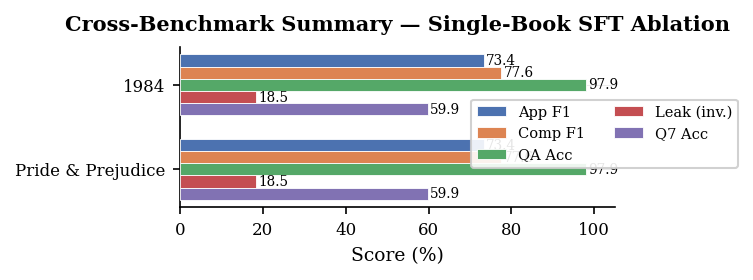

In [9]:
# ── Figure 2: Cross-benchmark horizontal grouped bars ────────────────────

summary_metrics = {
    "App F1":          ("App F1",    False),
    "Comp F1":         ("Comp F1",   False),
    "QA Acc":          ("QA Acc",    False),
    "Leak (inv.)":     ("Leak Rate", True),
    "Q7 Acc":          ("Q7 Acc",    False),
}
summary_metrics = {k: v for k, v in summary_metrics.items()
                   if v[0] in df_table.columns and df_table[v[0]].notna().any()}

n_metrics = len(summary_metrics)
n_books = len(books)
bar_h = 0.72 / n_metrics
y = np.arange(n_books)
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

fig, ax = plt.subplots(figsize=(5.5, 0.52 * n_books + 0.9))

for j, (disp_label, (col, invert)) in enumerate(summary_metrics.items()):
    offset = (j - (n_metrics - 1) / 2) * bar_h
    vals = df_table[col].reindex(books).values.copy()
    if invert:
        vals = np.where(np.isnan(vals), np.nan, 100 - vals)
    bars = ax.barh(y + offset, vals, bar_h, label=disp_label,
                   color=metric_colors[j % len(metric_colors)],
                   edgecolor="white", linewidth=0.4, zorder=3)
    for bar, v in zip(bars, vals):
        if pd.notna(v) and v > 0:
            ax.text(bar.get_width() + 0.5,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.1f}", ha="left", va="center", fontsize=6.5)

ax.set_yticks(y)
ax.set_yticklabels(book_labels, fontsize=8)
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 105)
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax.legend(loc="lower right", framealpha=0.9, ncol=2, fontsize=7, bbox_to_anchor=(1.3, 0.2))
ax.set_title("Cross-Benchmark Summary \u2014 Single-Book SFT Ablation",
             fontsize=10, fontweight="bold", pad=8)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig("tables/single_book_cross_benchmark.pdf")
plt.show()